# Purdue MSDS GRAD 50500 Project Deliverable 3 - Stephen Codoluto

# Table of Contents

### [Exploratory Data Analysis](#Exploratory-Data-Analysis)


### [Data Preparation](#Data_Preparation)


### [Research Question 1: What-physical-attributes-of-a-home-most-strongly-predict-its-sale-price?](#Research-Q1:-What-physical-attributes-of-a-home-most-strongly-predict-its-sale-price?)


### [Research Question 2: Does-neighborhood-significantly-affect-home-sale-prices-with-house-size,-quality,-and-other-impactful-variables-controlled?](#Research-Q2:-Does-neighborhood-significantly-affect-home-sale-prices-with-house-size,-quality,-and-other-impactful-variables-controlled?)


### [Research Question 3: Can-it-be-predicted-whether-a-house-will-sell-above-the-median-price-based-on-its-features?](#Research-Q3:-Can-it-be-predicted-whether-a-house-will-sell-above-the-median-price-based-on-its-features?)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn import metrics, linear_model, preprocessing
from sklearn.linear_model import LinearRegression, LogisticRegression
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

## Exploratory Data Analysis

In [2]:
''' Import the dataset. I'm selecting 400 of the 2900+ rows
to make the dataset more manageable and to potentially test some of the
correlation predictions in the future on data not imported. '''
AmesData = pd.read_csv('Ames_Dataset.csv', nrows=400)
AmesData.head()

,Order,PID,area,price,MS.SubClass,MS.Zoning,Lot.Frontage,Lot.Area,Street,Alley,...,Screen.Porch,Pool.Area,Pool.QC,Fence,Misc.Feature,Misc.Val,Mo.Sold,Yr.Sold,Sale.Type,Sale.Condition
0,1,526301100,1656,215000,20,RL,141.0,31770,Pave,NaN,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
1,2,526350040,896,105000,20,RH,80.0,11622,Pave,NaN,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
2,3,526351010,1329,172000,20,RL,81.0,14267,Pave,NaN,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
3,4,526353030,2110,244000,20,RL,93.0,11160,Pave,NaN,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
4,5,527105010,1629,189900,60,RL,74.0,13830,Pave,NaN,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal


In [3]:
AmesData.shape

(400, 82)

In [4]:
# Exploratory only, output was fairly lengthy
# AmesData.info() 

In [5]:
AmesData.describe()

,Order,PID,area,price,MS.SubClass,Lot.Frontage,Lot.Area,Overall.Qual,Overall.Cond,Year.Built,...,Wood.Deck.SF,Open.Porch.SF,Enclosed.Porch,X3Ssn.Porch,Screen.Porch,Pool.Area,Pool.QC,Misc.Val,Mo.Sold,Yr.Sold
count,400.000000,4.000000e+02,400.000000,400.000000,400.00000,329.000000,400.000000,400.000000,400.000000,400.000000,...,400.0000,400.00000,400.000000,400.000000,400.000000,400.0,0.0,400.000000,400.000000,400.000000
mean,200.500000,6.929294e+08,1479.982500,177155.422500,57.52500,69.021277,9804.022500,6.022500,5.575000,1971.992500,...,101.3625,40.50500,22.725000,2.785000,15.137500,0.0,NaN,80.385000,4.677500,2009.852500
std,115.614301,1.875850e+08,466.264086,75405.656896,43.69379,21.712145,5050.997131,1.336585,1.139131,28.611694,...,133.7951,55.08244,60.847394,30.962728,56.204011,0.0,NaN,679.769636,2.013362,0.355048
min,1.000000,5.263011e+08,540.000000,12789.000000,20.00000,21.000000,1476.000000,2.000000,1.000000,1875.000000,...,0.0000,0.00000,0.000000,0.000000,0.000000,0.0,NaN,0.000000,1.000000,2009.000000
25%,100.750000,5.281201e+08,1119.250000,128837.500000,20.00000,57.000000,7500.000000,5.000000,5.000000,1957.000000,...,0.0000,0.00000,0.000000,0.000000,0.000000,0.0,NaN,0.000000,3.000000,2010.000000
50%,200.500000,5.351521e+08,1443.000000,160125.000000,50.00000,70.000000,9515.000000,6.000000,5.000000,1975.000000,...,0.0000,20.50000,0.000000,0.000000,0.000000,0.0,NaN,0.000000,5.000000,2010.000000
75%,300.250000,9.054530e+08,1729.000000,210500.000000,71.25000,80.000000,11383.500000,7.000000,6.000000,1998.000000,...,192.0000,63.25000,0.000000,0.000000,0.000000,0.0,NaN,0.000000,6.000000,2010.000000
max,400.000000,9.241520e+08,3279.000000,611657.000000,190.00000,152.000000,57200.000000,9.000000,9.000000,2010.000000,...,668.0000,312.00000,364.000000,508.000000,490.000000,0.0,NaN,12500.000000,12.000000,2010.000000


In [6]:
median_pr = AmesData['price'].median()
median_pr

160125.0

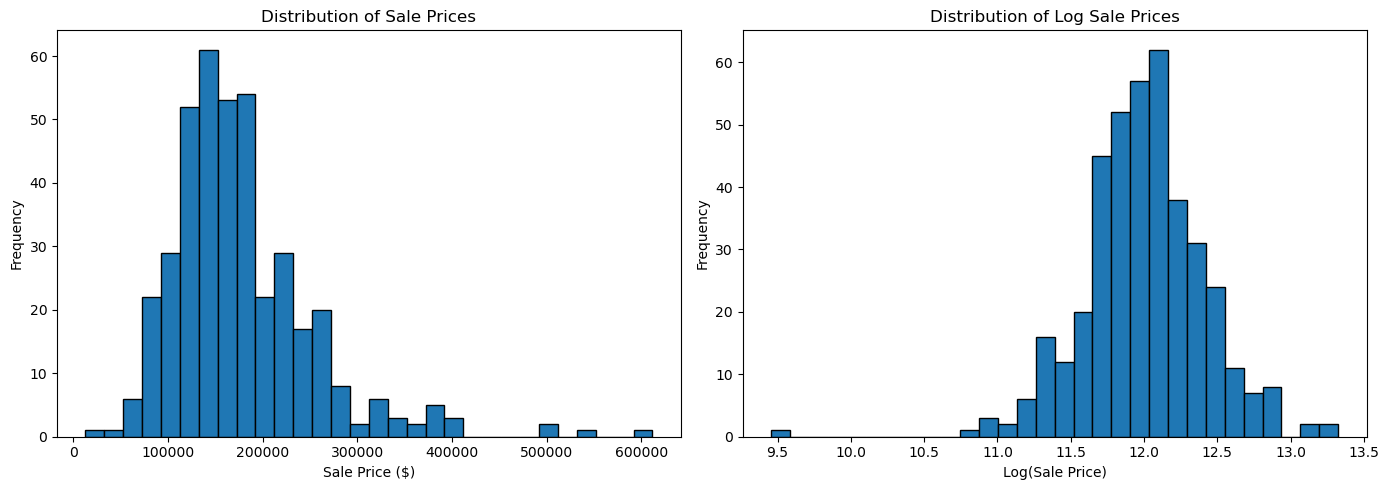

In [9]:
# plots the sale price and log normalized histogram of sale price

salePrice = AmesData['price']
salePrice.describe()

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))

ax1.hist(salePrice, bins=30, edgecolor='black')
ax1.set_xlabel('Sale Price ($)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Sale Prices')

ax2.hist(np.log(salePrice), bins = 30, edgecolor = 'black')
ax2.set_xlabel('Log(Sale Price)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Log Sale Prices')

plt.tight_layout()
plt.show()

In [5]:
# calculates the skewness of the SalePrice
salePrice.skew()

np.float64(1.7006482877337616)

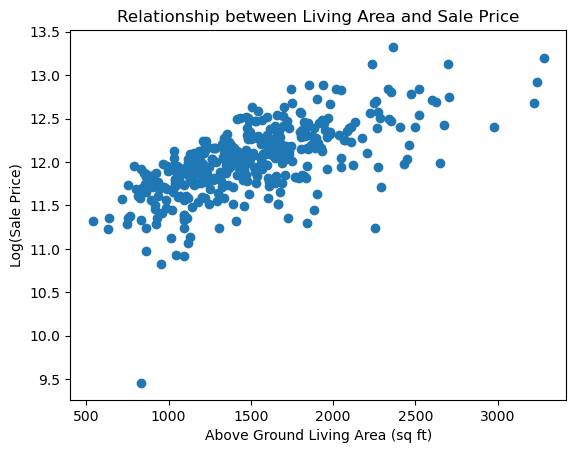

In [10]:
#plots and shows the GrLivArea variable dataset for a rough visualization of correlation
fig2 = np.log(salePrice)
plt.scatter(AmesData['area'], fig2)
plt.xlabel('Above Ground Living Area (sq ft)')
plt.ylabel('Log(Sale Price)')
plt.title('Relationship between Living Area and Sale Price')
plt.show()

In [11]:
# provides a summary of null values for each Column
nulls = pd.DataFrame(AmesData.isnull().sum().sort_values(ascending=False)[0:10])
nulls

,0
Pool.QC,400
Alley,380
Misc.Feature,374
Fence,313
Mas.Vnr.Type,248
Fireplace.Qu,198
Lot.Frontage,71
Garage.Qual,24
Garage.Type,24
Garage.Finish,24


## Data_Preparation

### Based on the exploratory data analysis, there are several issues with the dataset that must be addressed prior to working on the research questions. The following is a list of data preparation steps to clean the data:
- Several columns have a significant proportion of data missing. Any columns with > 60% data missing and will be removed.
- The 'Order' and 'PID' columns are not needed for analysis so they will be removed.
- Categorical and numeric columns have several missing/NA values that need to be filled.
- Lot frontage column has several missing values. A median of lot frontage will be used to impute these values.
- The final clean dataset will be exported to cvs for manual validation.

[Back to Table of Contents](#Table-of-Contents)

In [12]:
# drop columns with 60% of data missing. 60% was selected after trialing other fractions. +/-20% here didn't make a big difference.
# drop PID and Order columns as they are not needed
threshold = 0.6
missing_pct = AmesData.isnull().sum() / len(AmesData)
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()
cols_to_drop.extend(['Order', 'PID'])
cols_to_drop

['Alley', 'Mas.Vnr.Type', 'Pool.QC', 'Fence', 'Misc.Feature', 'Order', 'PID']

In [13]:
# create a separate df
clean_data = AmesData.drop(columns=cols_to_drop)

In [14]:
# Features where missing data indicates a feature doesn't exist
fill_none = ['Garage.Type', 'Garage.Finish', 'Garage.Qual', 'Garage.Cond',
    'Bsmt.Qual', 'Bsmt.Cond', 'Bsmt.Exposure', 'BsmtFin.Type.1', 'BsmtFin.Type.2',
    'Fireplace.Qu', 'Mas.Vnr.Type']

# Numeric features where missing = 0
fill_zero = ['Garage.Yr.Blt', 'Garage.Cars', 'Garage.Area',
    'BsmtFin.SF.1', 'BsmtFin.SF.2', 'Bsmt.Unf.SF', 'Total.Bsmt.SF',
    'Bsmt.Full.Bath', 'Bsmt.Half.Bath', 'Mas.Vnr.Area']

# Fill missing values
fill_values = {col: 'None' for col in fill_none if col in clean_data.columns}
fill_values.update({col: 0 for col in fill_zero if col in clean_data.columns})
clean_data = clean_data.fillna(fill_values)

# Impute lot frontage column with median
if clean_data['Lot.Frontage'].isnull().any(): 
    clean_data['Lot.Frontage'] = clean_data['Lot.Frontage'].fillna(clean_data['Lot.Frontage'].median())

# Export and validate clean dataset
clean_data.to_csv("Ames_Clean_Data.csv")

In [15]:
# Check cleaned data for nulls to ensure data was cleaned
sum(clean_data.isnull().sum()!=0 )

0

### Research Q1: What physical attributes of a home most strongly predict its sale price?

[Back to Table of Contents](#Table-of-Contents)

### Hypothesis for research question 1. H_0 for this research question would be that the physical attribute regression coefficients to sale price are all zero. H_1 would be at least one of the physical attributes correlates to sale price and does not equal zero. Using alpha = 0.05.
#### H_0: All regression coefficients = 0.
#### H_1: At least one regression coefficient =! 0. 

In [16]:
numeric_cols = clean_data.select_dtypes(include = [np.number]).columns.tolist()
numeric_cols.remove('price') # this would correlate price against itself which doesn't make sense.

# Currently excluding neighborhood because 1) it is not numeric and 2) I will look at this variable in question 2. 

correlations = clean_data[numeric_cols + ['price']].corr()['price'].drop('price')
top_10_corr = correlations.abs().sort_values(ascending = False).head(10)

top_10_corr_table = pd.DataFrame({'Physical Attribute': top_10_corr.index,'Correlation': [correlations[feat] for feat in top_10_corr.index]})

top_10_corr_table

,Physical Attribute,Correlation
0,Overall.Qual,0.768052
1,area,0.687411
2,Total.Bsmt.SF,0.660860
3,X1st.Flr.SF,0.643626
4,Garage.Cars,0.631831
5,Garage.Area,0.610352
6,Year.Built,0.582074
7,Year.Remod.Add,0.531232
8,Full.Bath,0.485870
9,TotRms.AbvGrd,0.482002


### Statistical Test: Multiple Regression

In [17]:
# select physical features that most strongly correlate with sale price
features = ['Overall.Qual', 'area', 'Total.Bsmt.SF', 'Garage.Cars', 'Year.Built', 'Year.Remod.Add']

x = clean_data[features]    # predictor variables
y = clean_data['price']        # Response variable

# Add a constant to the predictors (intercept term)
x = sm.add_constant(x)

# Fit the linear regression model
model_q1 = sm.OLS(y, x).fit()

print(model_q1.summary())

print('\n Stats')
print(f' R-squared: {model_q1.rsquared:.3f}')
print(f' F-statistic: {model_q1.fvalue:.2f}')
print(f' Prob (F-statistic): {model_q1.f_pvalue:.6f}')

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.815
Model:                            OLS   Adj. R-squared:                  0.813
Method:                 Least Squares   F-statistic:                     289.3
Date:                Thu, 19 Feb 2026   Prob (F-statistic):          8.60e-141
Time:                        20:42:58   Log-Likelihood:                -4721.4
No. Observations:                 400   AIC:                             9457.
Df Residuals:                     393   BIC:                             9485.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -1.311e+06   2.09e+05     -6.

### Assumptions Met and Verified?

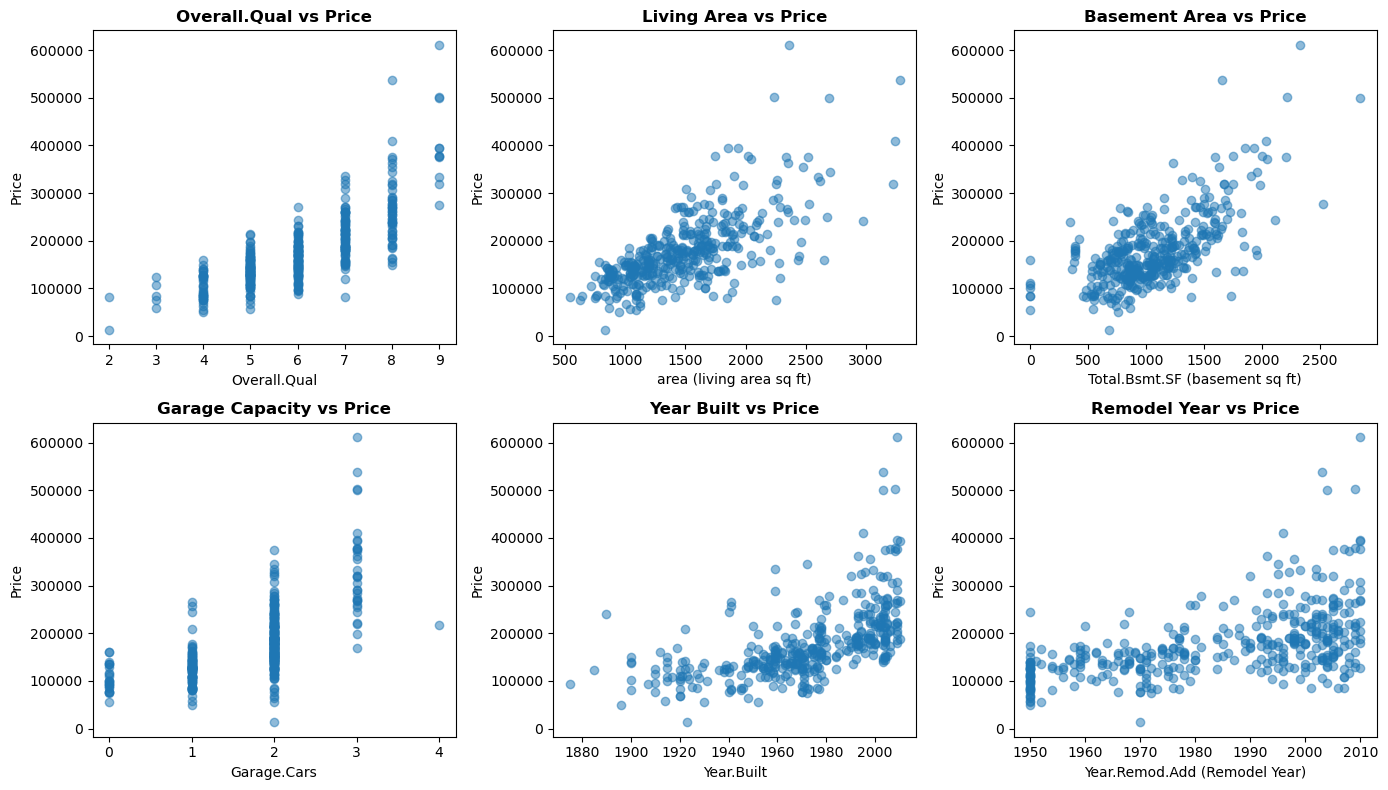

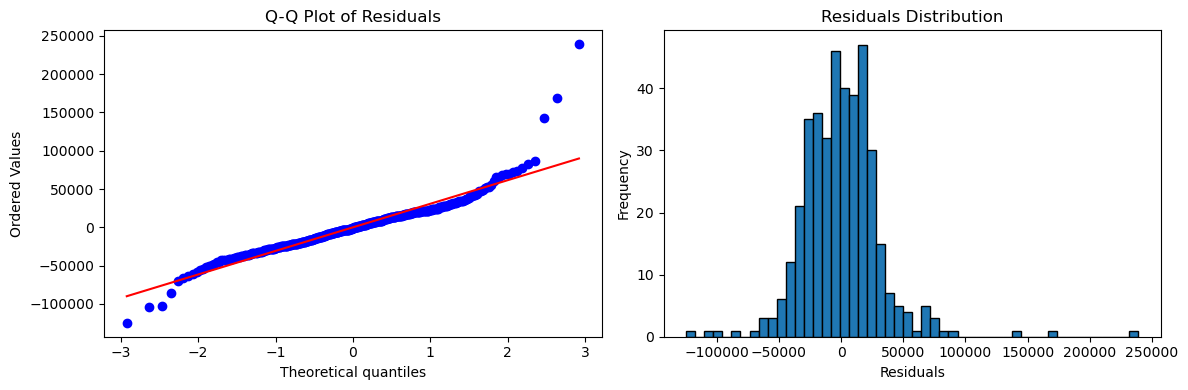

In [21]:
# Check linearity of features against price using scatter plots
fig3, axes = plt.subplots(2, 3, figsize = (14, 8))

# Overall.Qual vs Price
axes[0, 0].scatter(clean_data['Overall.Qual'], clean_data['price'], alpha = 0.5)
axes[0, 0].set_xlabel('Overall.Qual')
axes[0, 0].set_ylabel('Price')
axes[0, 0].set_title('Overall.Qual vs Price', fontweight = 'bold')

# area vs Price
axes[0, 1].scatter(clean_data['area'], clean_data['price'], alpha = 0.5)
axes[0, 1].set_xlabel('area (living area sq ft)')
axes[0, 1].set_ylabel('Price')
axes[0, 1].set_title('Living Area vs Price', fontweight = 'bold')

# Total.Bsmt.SF vs Price
axes[0, 2].scatter(clean_data['Total.Bsmt.SF'], clean_data['price'], alpha = 0.5)
axes[0, 2].set_xlabel('Total.Bsmt.SF (basement sq ft)')
axes[0, 2].set_ylabel('Price')
axes[0, 2].set_title('Basement Area vs Price', fontweight = 'bold')

# Garage.Cars vs Price
axes[1, 0].scatter(clean_data['Garage.Cars'], clean_data['price'], alpha = 0.5)
axes[1, 0].set_xlabel('Garage.Cars')
axes[1, 0].set_ylabel('Price')
axes[1, 0].set_title('Garage Capacity vs Price', fontweight = 'bold')

# Year.Built vs Price
axes[1, 1].scatter(clean_data['Year.Built'], clean_data['price'], alpha = 0.5)
axes[1, 1].set_xlabel('Year.Built')
axes[1, 1].set_ylabel('Price')
axes[1, 1].set_title('Year Built vs Price', fontweight = 'bold')

# Year.Remod.Add vs Price
axes[1, 2].scatter(clean_data['Year.Remod.Add'], clean_data['price'], alpha = 0.5)
axes[1, 2].set_xlabel('Year.Remod.Add (Remodel Year)')
axes[1, 2].set_ylabel('Price')
axes[1, 2].set_title('Remodel Year vs Price', fontweight = 'bold')

plt.tight_layout()
plt.show()

# Check residuals
residuals = model_q1.resid

fig4, axes = plt.subplots(1, 2, figsize = (12, 4))

# Q-Q plot
stats.probplot(residuals, dist = 'norm', plot = axes[0])
axes[0].set_title('Q-Q Plot of Residuals')

# Histogram
axes[1].hist(residuals, bins = 50, edgecolor = 'black')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residuals Distribution')

plt.tight_layout()
plt.show()

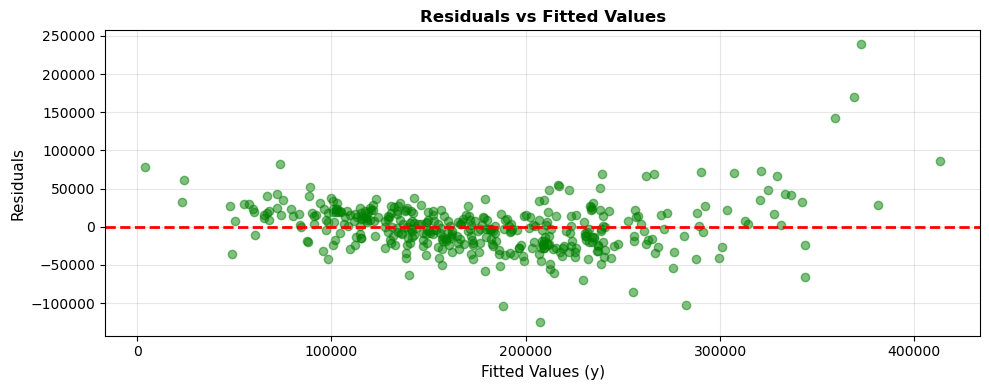

Constant variance: Should not have a fanning out / funneling in look
Mean of 0: Residuals should not be uniformly above 0 or uniformly below 0 for any subsection
Independence: Shouldn’t see any clear patterns.


In [19]:
# Check for constant variance. Plot residuals vs. y. Should not have a fanning out / funneling in look.

fitted_values = model_q1.fittedvalues

fig5, ax = plt.subplots(1, 1, figsize = (10, 4))

ax.scatter(fitted_values, residuals, alpha = 0.5, color = 'green')
ax.axhline(y = 0, color = 'red', linestyle = '--', linewidth = 2)
ax.set_xlabel('Fitted Values (y)', fontsize = 11)
ax.set_ylabel('Residuals', fontsize = 11)
ax.set_title('Residuals vs Fitted Values', fontsize = 12, fontweight = 'bold')
ax.grid(alpha = 0.3)

# Independence: Plot residuals vs. 𝑦 ̂. Shouldn’t see any clear patterns.
# Mean of 0: Plot residuals vs. 𝑦. Residuals should not be uniformly above 0 or uniformly below 0 for any subsection. 

plt.tight_layout()
plt.show()

print('Constant variance: Should not have a fanning out / funneling in look')
print('Mean of 0: Residuals should not be uniformly above 0 or uniformly below 0 for any subsection')
print('Independence: Shouldn’t see any clear patterns.')

#### Regression assumptions were verified and met, including linearity and residuals normality.

### Accept or reject the hypothesis
### Based on the results above, at least one physical attribute predicts sale price so we reject H_0. 
### The F-test p-value < 0.0001

<function matplotlib.pyplot.show(close=None, block=None)>

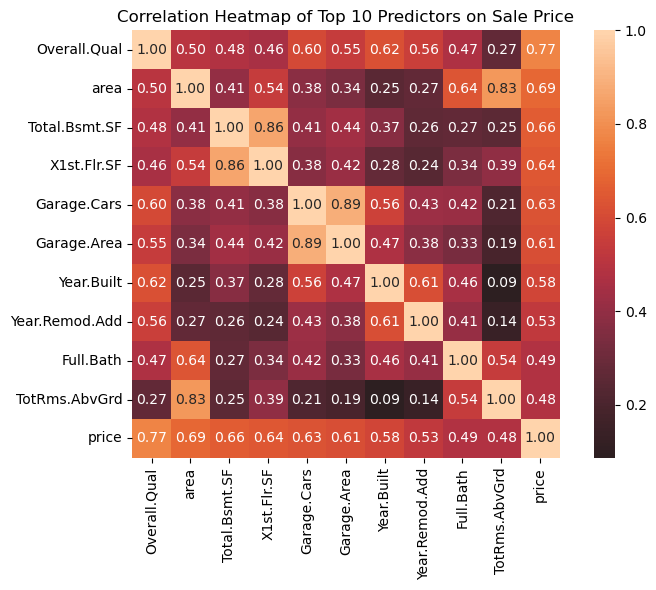

In [20]:
top_features = top_10_corr.index.tolist() + ['price']
fig6 = clean_data[top_features].corr()

plt.figure(figsize = (8, 6))
sns.heatmap(fig6, annot = True, center = 0, fmt = '.2f', square = True)
plt.title('Correlation Heatmap of Top 10 Predictors on Sale Price')
plt.tight_layout()
plt.show

### Research Q2: Does neighborhood significantly affect home sale prices with house size, quality, and other impactful variables controlled?

[Back to Table of Contents](#Table-of-Contents)

### Hypothesis for research question 2. H_0 for this research question would be that the neighborhood has no effect on price after controlling for physical attributes. H_1 would be that neighborhood has an effect on price after controlling for physical attributes using alpha = 0.05.
#### H_0: Neighborhood has no effect on price after controlling for physical attributes.
#### H_1: Neighborhood has a significant effect on price after controlling for physical attributes.

### Statistical Test: ANOVA

In [27]:
neighborhood_counts = clean_data['Neighborhood'].value_counts()

# Only include neighborhoods with at least 5 houses.
pop_neighborhoods = neighborhood_counts[neighborhood_counts >= 5].index

filtered_neighborhoods = clean_data[clean_data['Neighborhood'].isin(pop_neighborhoods)].copy()

# Physical attributes only
x1 = filtered_neighborhoods[features]
y = filtered_neighborhoods['price']
x1 = sm.add_constant(x1)
model_1 = sm.OLS(y, x1).fit()

# Physical attributes + Neighborhood
neighborhood_dummies = pd.get_dummies(filtered_neighborhoods['Neighborhood'], prefix = 'Neighborhood', drop_first = True)
x2 = pd.concat([filtered_neighborhoods[features], neighborhood_dummies], axis = 1)
x2 = x2.astype(float)

x2 = sm.add_constant(x2)
model_2 = sm.OLS(y, x2).fit()

print(f' Model 1: Physical Attributes Only R^2 = {model_1.rsquared:.4f}')
print(f' Model 2: Physical Attributes and Neighborhood R^2 = {model_2.rsquared:.4f}')
print(f'\n R^2 improvement from adding neighborhood = {model_2.rsquared - model_1.rsquared:.4f}')

anova_results = anova_lm(model_1, model_2)
print(anova_results)

print(f'\n F-statistic: {anova_results['F'][1]:.6f}')
print(f'\n P value: {anova_results['Pr(>F)'][1]:.6f}')

 Model 1: Physical Attributes Only R^2 = 0.8163
 Model 2: Physical Attributes and Neighborhood R^2 = 0.8415

 R^2 improvement from adding neighborhood = 0.0252
   df_resid           ssr  df_diff       ss_diff         F    Pr(>F)
0     380.0  4.112423e+11      0.0           NaN       NaN       NaN
1     361.0  3.549244e+11     19.0  5.631788e+10  3.014839  0.000029

 F-statistic: 3.014839

 P value: 0.000029


### Assumptions Met and Verified?

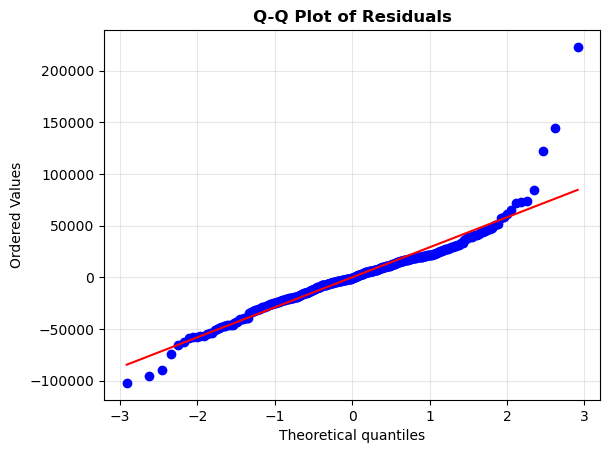

In [28]:
residuals_2 = model_2.resid

fig7, ax = plt.subplots()

# Q-Q plot of residuals
stats.probplot(residuals_2, dist = "norm", plot = ax)
ax.set_title('Q-Q Plot of Residuals', fontweight = 'bold')
ax.grid(True, alpha = 0.3)

plt.show()

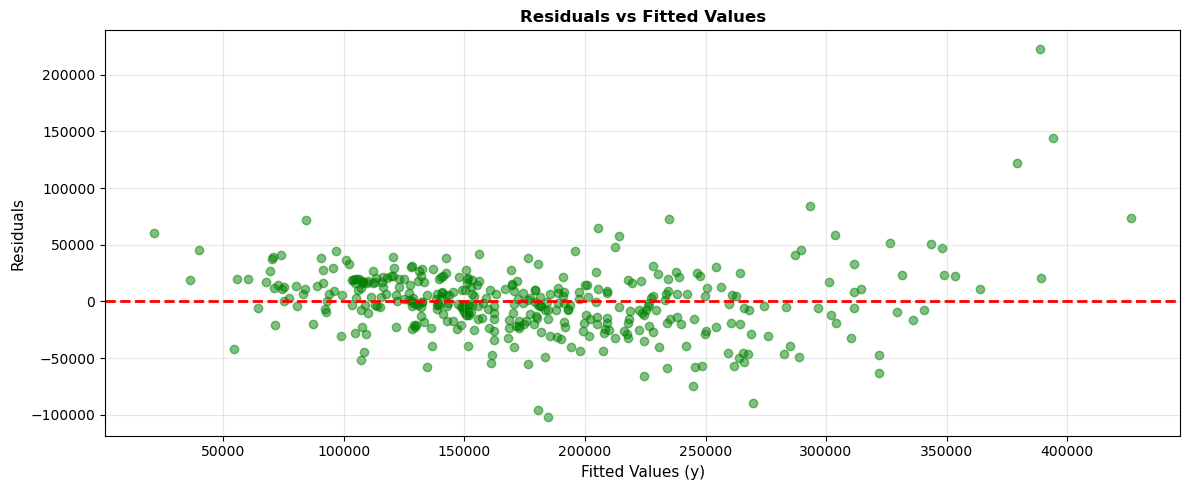

Constant variance: Should not have a fanning out / funneling in look
Mean of 0: Residuals should not be uniformly above 0 or uniformly below 0 for any subsection
Independence: Shouldn’t see any clear patterns.


In [32]:
# Check for constant variance. Plot residuals vs. y. Should not have a fanning out / funneling in look.

fitted_values_2 = model_2.fittedvalues

fig8, ax = plt.subplots(1, 1, figsize = (12, 5))

ax.scatter(fitted_values_2, residuals_2, alpha = 0.5, color = 'green')
ax.axhline(y = 0, color = 'red', linestyle = '--', linewidth = 2)
ax.set_xlabel('Fitted Values (y)', fontsize = 11)
ax.set_ylabel('Residuals', fontsize = 11)
ax.set_title('Residuals vs Fitted Values', fontsize = 12, fontweight = 'bold')
ax.grid(alpha = 0.3)

# Independence: Plot residuals vs. y ̂. Shouldn’t see any clear patterns.
# Mean of 0: Plot residuals vs. y. Residuals should not be uniformly above 0 or uniformly below 0 for any subsection. 

plt.tight_layout()
plt.show()

print('Constant variance: Should not have a fanning out / funneling in look')
print('Mean of 0: Residuals should not be uniformly above 0 or uniformly below 0 for any subsection')
print('Independence: Shouldn’t see any clear patterns.')

In [23]:
# confirm neighborhoods that had at least 5 houses were mapped
print(f' Neighborhood coded as {neighborhood_dummies.shape[1]} dummy variables')

neighborhood_counts = filtered_neighborhoods['Neighborhood'].value_counts()
print(f'\n Sample Size per Neighborhood')
print(f'   Minimum houses: {neighborhood_counts.min()}')
print(f'   Maximum houses: {neighborhood_counts.max()}')

 Neighborhood coded as 19 dummy variables

 Sample Size per Neighborhood
   Minimum houses: 7
   Maximum houses: 69


#### The ANOVA F-test depends on the same assumptions as outlined in question 1 in terms of linearity and normality of residuals. 

#### A couple additional checks in question 2 include:
- Confirmed Neighborhoods with at least 5 houses were mapped to the dummy variables.
- After reviewing the results I went back and modified the neighborhoods to be considered so that the observations per neighborhood were at least 5 to have an adequate sample size. This was validated above with the printout of min/max houses per neighborhood.

### Accept or reject the hypothesis

### Based on the results above, Neighborhood significantly affects sale price beyond physical attributes as calculated by the F test showing a p value of 0.000029 < 0.05 so we reject H_0. Although statistically significant when using the F-test, the overall Neighborhood effect relative to the top correlated physical features is small.

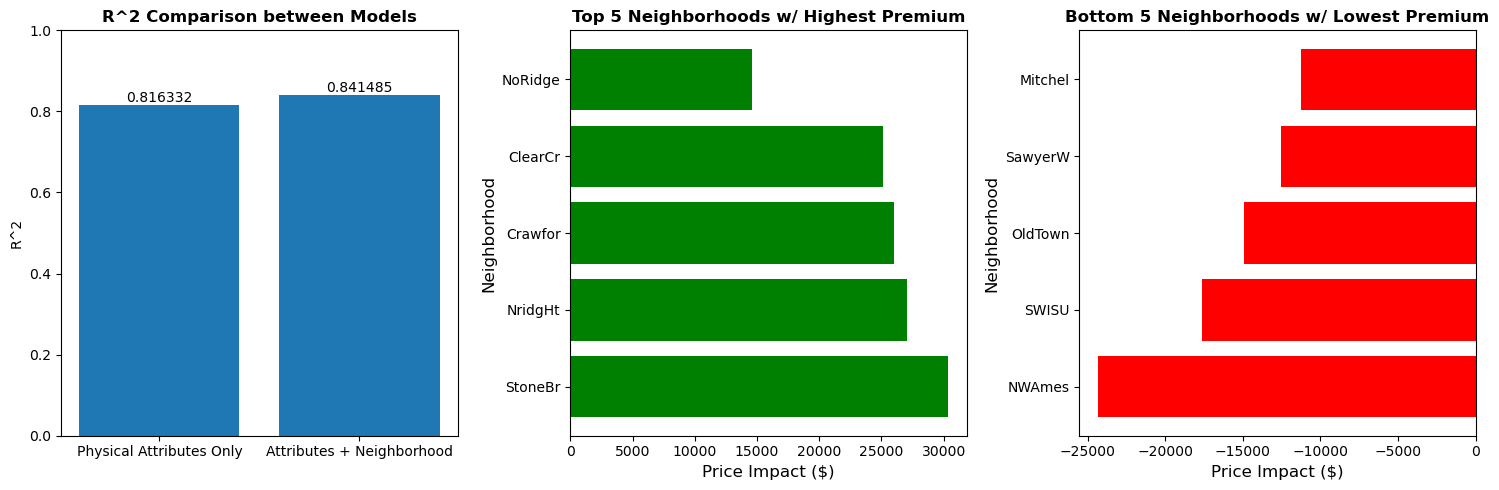

In [33]:
fig9, axes = plt.subplots(1, 3, figsize = (15, 5))

# R squared comparison
bar_chart = axes[0].bar(['Physical Attributes Only', 'Attributes + Neighborhood'], [model_1.rsquared, model_2.rsquared])
axes[0].set_ylabel('R^2')
axes[0].set_title('R^2 Comparison between Models', fontsize = 12, fontweight = 'bold')
axes[0].set_ylim([0, 1])
axes[0].bar_label(bar_chart)

# Top 5 Neighborhoods w/ Highest Premium
coefficients = model_2.params
neighborhood_only = coefficients[coefficients.index.str.contains('Neighborhood')]
neighborhood_sorted = neighborhood_only.sort_values(ascending = False)
top_5 = neighborhood_sorted.head(5)
neighborhoods_top = [name.replace('Neighborhood_', '') for name in top_5.index]
prices = top_5.values

axes[1].barh(neighborhoods_top, prices, color = 'green')
axes[1].set_ylabel('Neighborhood', fontsize = 12)
axes[1].set_xlabel('Price Impact ($)', fontsize = 12)
axes[1].set_title('Top 5 Neighborhoods w/ Highest Premium', fontsize = 12, fontweight = 'bold')

# Bottom 5 Neighborhoods w/ Lowest Premium
neighborhood_sorted_2 = neighborhood_only.sort_values(ascending = True)
bottom_5 = neighborhood_sorted_2.head(5)
neighborhoods_bottom = [name.replace('Neighborhood_', '') for name in bottom_5.index]
prices = bottom_5.values

axes[2].barh(neighborhoods_bottom, prices, color = 'red')
axes[2].set_ylabel('Neighborhood', fontsize = 12)
axes[2].set_xlabel('Price Impact ($)', fontsize = 12)
axes[2].set_title('Bottom 5 Neighborhoods w/ Lowest Premium', fontsize = 12, fontweight = 'bold')

plt.tight_layout()
plt.show()

## Additional Code and Analysis from Project Deliverable 2

In [34]:
neighborhood_stats = clean_data.groupby('Neighborhood').agg({'price': ['count', 'mean', 'median', 'std', 'min', 'max']}).round(0)
neighborhood_stats.columns = ['Count', 'Mean_Price', 'Median_Price', 'Std_Dev', 'Min_Price', 'Max_Price']
neighborhood_stats = neighborhood_stats.sort_values('Mean_Price', ascending = False)
neighborhood_stats

,Count,Mean_Price,Median_Price,Std_Dev,Min_Price,Max_Price
Neighborhood,,,,,,
NridgHt,15,312823.0,290941.0,118576.0,175500,611657
NoRidge,10,303207.0,307500.0,67402.0,190000,410000
StoneBr,14,302876.0,250000.0,114387.0,187500,538000
Crawfor,7,258876.0,257500.0,44647.0,203135,335000
Timber,8,224948.0,208900.0,70740.0,160000,378500
ClearCr,8,220988.0,237200.0,71256.0,107500,328000
Somerst,25,211738.0,220000.0,43123.0,147110,271500
CollgCr,21,198279.0,198900.0,49459.0,127000,318000
Gilbert,33,192549.0,185000.0,39768.0,141000,377500


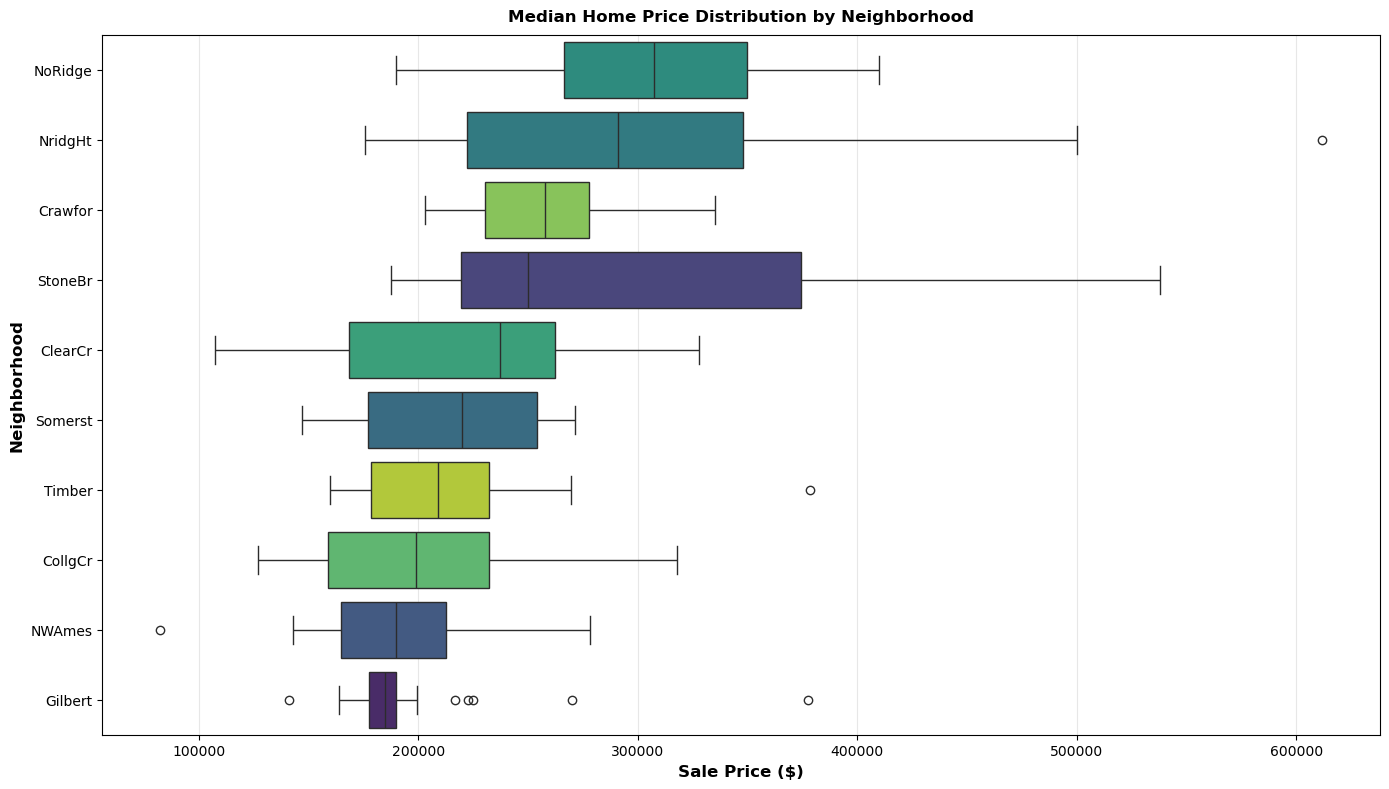

In [35]:
top_10_neighborhoods = neighborhood_stats.head(10).index.tolist()
top10 = clean_data[clean_data['Neighborhood'].isin(top_10_neighborhoods)]

fig8, ax = plt.subplots(figsize = (14, 8))
neighborhood_order = top10.groupby('Neighborhood')['price'].median().sort_values(ascending = False).index
sns.boxplot(data = top10, y = 'Neighborhood', x = 'price', order = neighborhood_order, palette = 'viridis', hue = 'Neighborhood', ax = ax)
ax.set_xlabel('Sale Price ($)', fontsize = 12, fontweight = 'bold')
ax.set_ylabel('Neighborhood', fontsize = 12, fontweight = 'bold')
ax.set_title('Median Home Price Distribution by Neighborhood', fontsize = 12, fontweight = 'bold', pad = 10)
ax.grid(axis = 'x', alpha = 0.3)
plt.tight_layout()

In [36]:
# Physical attributes to control (top correlated variables found in Q1, leaving out Garage.Area as I felt that was redundant with Garage.Cars)
physical_features = [
    'Overall.Qual',      # Quality rating
    'area',              # Total living area
    'Total.Bsmt.SF',     # Basement square footage
    'X1st.Flr.SF',       # First floor square footage
    'Garage.Cars',       # Garage capacity (excluding Garage.Area as redundant)
    'Year.Built',        # Year built (not creating House_Age)
    'Year.Remod.Add',    # Year remodeled
    'Full.Bath'          # Number of full bathrooms
]

In [37]:
neighborhood_counts = clean_data['Neighborhood'].value_counts()
neighborhood_counts.head(20)

Neighborhood
NAmes      69
Gilbert    33
NWAmes     29
OldTown    29
Somerst    25
Sawyer     23
Edwards    23
CollgCr    21
SawyerW    18
Mitchel    17
NridgHt    15
StoneBr    14
SWISU      11
BrkSide    11
NoRidge    10
IDOTRR      9
Timber      8
ClearCr     8
MeadowV     7
Crawfor     7
Name: count, dtype: int64

In [38]:
# Only include neighborhoods with at least 10 houses.
populated_neighborhoods = neighborhood_counts[neighborhood_counts >= 10].index
populated_neighborhoods

Index(['NAmes', 'Gilbert', 'NWAmes', 'OldTown', 'Somerst', 'Sawyer', 'Edwards',
       'CollgCr', 'SawyerW', 'Mitchel', 'NridgHt', 'StoneBr', 'SWISU',
       'BrkSide', 'NoRidge'],
      dtype='object', name='Neighborhood')

In [39]:
# test case to provide an example of controlling a couple variables
clean_data['Quality_Cat'] = pd.cut(clean_data['Overall.Qual'], bins = [0, 5, 7, 10], labels = ['Low (1-5)', 'Medium (6-7)', 'High (8-10)'])

clean_data['Size_Cat'] = pd.qcut(clean_data['area'], q = 3, labels = ['Small', 'Medium', 'Large'])

# Test of medium quality and medium size homes across neighborhoods
medium_quality_size = clean_data[(clean_data['Quality_Cat'] == 'Medium (6-7)') &
    (clean_data['Size_Cat'] == 'Medium') & (clean_data['Neighborhood'].isin(populated_neighborhoods))]

m_comparison = medium_quality_size.groupby('Neighborhood')['price'].agg([('Count', 'count'), ('Mean_Price', 'mean'), ('Std_Dev', 'std')
                                                                        ]).sort_values('Mean_Price', ascending = False).round(0)

# filtering to account for a couple neighborhoods that only had 1 or 2 counts
m_comparison = m_comparison[m_comparison['Count'] >= 3]

print("Price comparison between neighborhoods for similar medium quality and medium size homes\n")
m_comparison.head(10)

Price comparison between neighborhoods for similar medium quality and medium size homes



,Count,Mean_Price,Std_Dev
Neighborhood,,,
NridgHt,4,208375.0,22299.0
Somerst,10,206470.0,41222.0
SawyerW,3,193167.0,68495.0
CollgCr,5,189230.0,18925.0
Gilbert,16,182045.0,8274.0
NWAmes,10,168550.0,38465.0
NAmes,10,163350.0,32408.0
Sawyer,4,154100.0,16505.0
OldTown,5,138270.0,17612.0


In [40]:
X = clean_data[physical_features + ['price']].copy()
Y = X['price']
#drops price and assigns to X
X = X.drop(['price'], axis = 1)
X

,Overall.Qual,area,Total.Bsmt.SF,X1st.Flr.SF,Garage.Cars,Year.Built,Year.Remod.Add,Full.Bath
0,6,1656,1080,1656,2,1960,1960,1
1,5,896,882,896,1,1961,1961,1
2,6,1329,1329,1329,1,1958,1958,1
3,7,2110,2110,2110,2,1968,1968,2
4,5,1629,928,928,2,1997,1998,2
...,...,...,...,...,...,...,...,...
395,5,1180,1180,1180,2,1970,1970,1
396,5,1050,1043,1050,1,1971,1971,1
397,4,864,864,864,2,1970,1970,1
398,4,864,864,864,2,1970,1970,1


In [41]:
lr = linear_model.LinearRegression()
model = lr.fit(X,Y)
predictions = model.predict(X)
print(f"R^2 is: {model.score(X,Y):.4f}")

R^2 is: 0.8263


In [42]:
neighborhood_dummies = pd.get_dummies(clean_data['Neighborhood'], prefix = 'Neighborhood', drop_first = True) 

# Combine physical features with neighborhood dummies + price
X_combined = pd.concat([clean_data[physical_features], neighborhood_dummies, clean_data[['price']]], axis = 1).copy()
Y_combined = X_combined['price']
# Drops price and assigns to X_combined
X_combined = X_combined.drop(['price'], axis=1)

lr_combined = linear_model.LinearRegression()
model_combined = lr_combined.fit(X_combined, Y_combined)
predictions_combined = model_combined.predict(X_combined)
print(f"  R^2 is: {model_combined.score(X_combined, Y_combined):.4f}")

# incremental change
r2_inc = model_combined.score(X_combined, Y_combined) - model.score(X, Y)
print(f"Incremental R^2 from adding Neighborhood is {r2_inc:.4f} or {r2_inc*100:.2f}%")

  R^2 is: 0.8499
Incremental R^2 from adding Neighborhood is 0.0236 or 2.36%


(array([  3.,  14., 140., 186.,  44.,  10.,   0.,   1.,   1.,   1.]),
 array([-113825.73353473,  -79112.9215476 ,  -44400.10956047,
          -9687.29757335,   25025.51441378,   59738.3264009 ,
          94451.13838803,  129163.95037515,  163876.76236228,
         198589.57434941,  233302.38633653]),
 <BarContainer object of 10 artists>)

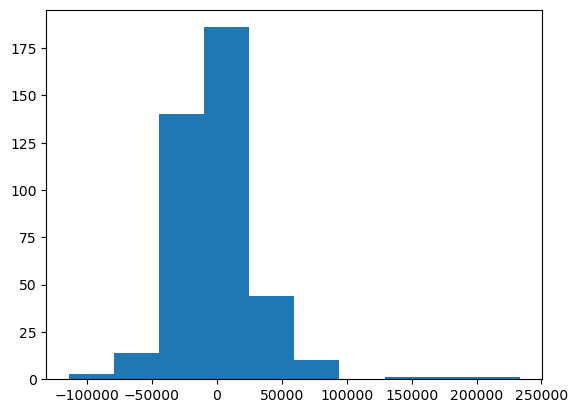

In [43]:
clean_data['Price_Residual'] = Y.values - predictions
plt.hist(clean_data['Price_Residual'])

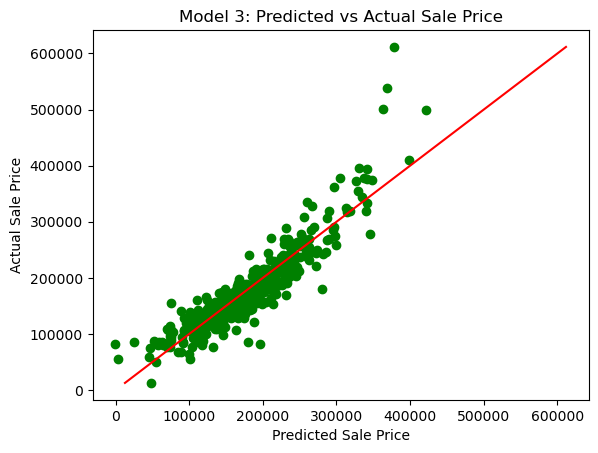

In [44]:
# Plots a scatter plot of Predictions vs Actual
plt.scatter(predictions, Y, color = 'green')
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r')
plt.xlabel('Predicted Sale Price')
plt.ylabel('Actual Sale Price')
plt.title(f'Model 3: Predicted vs Actual Sale Price')
plt.show()

In [45]:
# residuals, actual - predicted from physical attributes only
clean_data['Price_Residual'] = Y.values - predictions

# Positive residual means house sold for more than physical attributes predict

# group by neighborhood
residuals = clean_data.groupby('Neighborhood').agg({'Price_Residual': ['mean', 'std', 'count'], 'price': 'mean'}).round(0)

residuals.columns = ['Premium', 'Std Dev', 'Count', 'Avg Actual Price']
residuals = residuals.sort_values('Premium', ascending = False)

print("\nNeighborhood Price Premium controlling for physical attributes\n")
print(residuals.head(15).to_string())


Neighborhood Price Premium controlling for physical attributes

              Premium  Std Dev  Count  Avg Actual Price
Neighborhood                                           
Crawfor       27165.0  30202.0      7          258876.0
StoneBr       25492.0  61818.0     14          302876.0
ClearCr       24346.0  19108.0      8          220988.0
NridgHt       22872.0  67691.0     15          312823.0
IDOTRR        12195.0  38084.0      9           84423.0
BrkSide        6691.0  20278.0     11          128564.0
NoRidge        6685.0  25542.0     10          303207.0
Edwards        6234.0  32264.0     23          123279.0
MeadowV        1464.0  16940.0      7           87607.0
Timber          531.0  26801.0      8          224948.0
Gilbert          19.0  23857.0     33          192549.0
Somerst        -671.0  21840.0     25          211738.0
Sawyer        -1235.0  25099.0     23          135078.0
Mitchel       -1989.0  26299.0     17          179035.0
SWISU         -4116.0  21471.0     11  

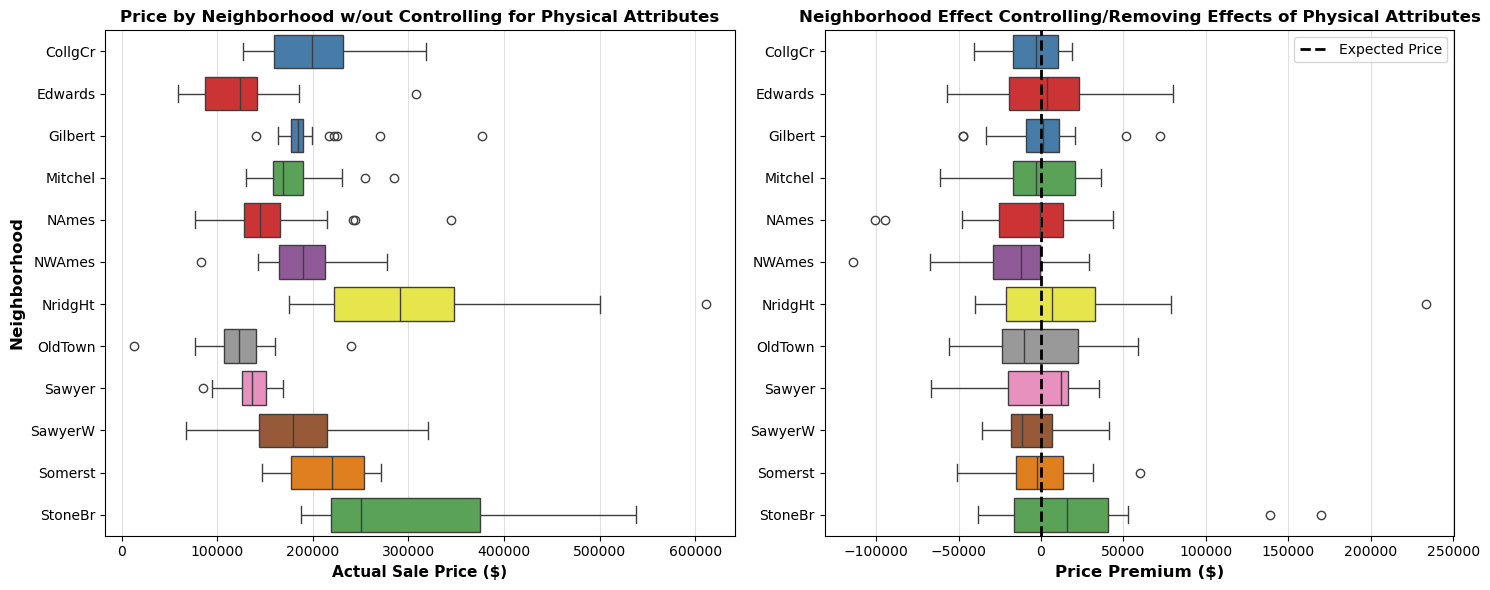

In [49]:
top_neighborhoods = clean_data['Neighborhood'].value_counts().head(12).index
df_top = clean_data[clean_data['Neighborhood'].isin(top_neighborhoods)]

fig9, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 6))

# Unadjusted price
neighborhood_order_alph = sorted(df_top['Neighborhood'])
sns.boxplot(data = df_top, y = 'Neighborhood', x = 'price', order = neighborhood_order_alph, hue = 'Neighborhood', palette = 'Set1', ax = ax1)
ax1.set_xlabel('Actual Sale Price ($)', fontsize = 11, fontweight = 'bold')
ax1.set_ylabel('Neighborhood', fontsize = 12, fontweight = 'bold')
ax1.set_title('Price by Neighborhood w/out Controlling for Physical Attributes', fontsize = 12, fontweight = 'bold')
ax1.grid(axis = 'x', alpha = 0.4)

# Residuals / adjusted price
neighborhood_order_alph_res = sorted(df_top['Neighborhood'])
sns.boxplot(data = df_top, y = 'Neighborhood', x = 'Price_Residual', order = neighborhood_order_alph_res, hue = 'Neighborhood', palette = 'Set1', ax = ax2)
ax2.set_xlabel('Price Premium ($)', fontsize = 12, fontweight = 'bold')
ax2.set_ylabel('')
ax2.set_title('Neighborhood Effect Controlling/Removing Effects of Physical Attributes', fontsize = 12, fontweight = 'bold')
ax2.axvline(x = 0, color = 'black', linestyle = '--', linewidth = 2, label = 'Expected Price')
ax2.grid(axis = 'x', alpha = 0.4)
ax2.legend()

plt.tight_layout()
plt.show()

## Research Q3: Can it be predicted whether a house will sell above the median price based on its features?

[Back to Table of Contents](#Table-of-Contents)

### Hypothesis for research question 3. H_0 for this research question would be that the model accuracy = 0.5 which would mean a random chance the home sells above median price. H_1 would be that the model accuracy > 0.5 which would indicate the model has a better than random chance at predicting a house will sell above the median price based on its features. Using alpha = 0.05.
#### H_0: Model accuracy = 0.5.
#### H_1: Model accuracy > 0.5 - better than random. 

In [50]:
# estimate median price
median_price = clean_data['price'].median()
print(f" Median Price is ${median_price:.0f}")

# 1 = above median, 0 = below median
clean_data['Above_Median'] = (clean_data['price'] > median_price).astype(int)

 Median Price is $160125


In [51]:
X_model = clean_data[features + ['Above_Median']].copy()
Y_model = X_model['Above_Median']
#drops price and assigns to X
X_model = X_model.drop(['Above_Median'], axis = 1)

# logistic regression used for binary aboive/below median 
lr = linear_model.LogisticRegression(max_iter = 1000)
model = lr.fit(X_model,Y_model)
predictions = model.predict(X_model)
probabilities = model.predict_proba(X_model)[:, 1]

model_score = model.score(X_model, Y_model)

print(f' Accuracy is: {model_score:.4f}')

 Accuracy is: 0.9025


In [53]:
feature_importance = pd.DataFrame({'Feature': features, 'Coefficient': np.abs(model.coef_[0])}).sort_values('Coefficient', ascending = False)

print("\nMost important features for predicting above/below median\n")
feature_importance


Most important features for predicting above/below median



,Feature,Coefficient
3,Garage.Cars,1.291016
0,Overall.Qual,0.661649
4,Year.Built,0.038258
5,Year.Remod.Add,0.023708
1,area,0.003946
2,Total.Bsmt.SF,0.002413


### Statistical Test: Binomial test for classification accuracy

In [55]:
# I initially found it strange that garage cars would be higher than overall.Qual and area and I realized these are absolute coefficients. 
# Changing garage cars from 1-4 has a larger impact than changing the livable sq footage (area) from 1-4 sq ft. 
# This is to somewhat normalize those features for a fair comparison.

scaler = preprocessing.StandardScaler()
X_model_scaled = scaler.fit_transform(X_model)

lr_scaled = linear_model.LogisticRegression(max_iter = 1000)
model_scaled = lr_scaled.fit(X_model_scaled, Y_model)

predictions_scaled = model_scaled.predict(X_model_scaled)
probabilities_scaled = model_scaled.predict_proba(X_model_scaled)[:, 1]
model_score_scaled = model_scaled.score(X_model_scaled, Y_model)

print(f' Accuracy is: {model_score_scaled:.4f}')

feature_importance_scaled = pd.DataFrame({'Feature': features,'Original_Coefficient': model.coef_[0], 
                                          'Standardized_Coefficient': np.abs(model_scaled.coef_[0])
                                         }).sort_values('Standardized_Coefficient', ascending = False)

feature_importance_scaled

 Accuracy is: 0.9025


,Feature,Original_Coefficient,Standardized_Coefficient
1,area,0.003946,1.691582
4,Year.Built,0.038258,0.980034
3,Garage.Cars,1.291016,0.968015
2,Total.Bsmt.SF,0.002413,0.928859
0,Overall.Qual,0.661649,0.859274
5,Year.Remod.Add,0.023708,0.470551


In [56]:
accuracy = model_score_scaled
n = len(predictions_scaled)
n_correct = np.sum(predictions_scaled == Y_model)

print(f' Total predictions: {n}')
print(f' Correct predictions: {n_correct}')
print(f' Accuracy: {accuracy*100:.2f}%')

 Total predictions: 400
 Correct predictions: 361
 Accuracy: 90.25%


In [57]:
# Binomial test
p_0 = 0.50
p = accuracy
z = (p - p_0) / np.sqrt(p_0 * (1 - p_0) / n)
p_value = 1 - stats.norm.cdf(z)

print(f' H_0: {p_0}')
print(f' Accuracy: {p:.4f}')
print(f' z-stat: {z:.4f}')
print(f' p-value: {p_value:.6f}')

 H_0: 0.5
 Accuracy: 0.9025
 z-stat: 16.1000
 p-value: 0.000000


In [64]:
z_crit = stats.norm.ppf((1 + 0.95) / 2)
std_error = np.sqrt(accuracy * (1 - accuracy) / n)
margin_of_error = z_crit * std_error
ci_lower = accuracy - margin_of_error
ci_upper = accuracy + margin_of_error
print(f' 95% CI for Accuracy: ({ci_lower*100:.2f}%, {ci_upper*100:.2f}%)')

 95% CI for Accuracy: (87.34%, 93.16%)


### Assumptions Met and Verified?

In [59]:
print('Binary Dependent Variable')
unique_values = Y_model.unique()
value_counts = Y_model.value_counts()
print(f' 0: (Below Median): {value_counts[0]}')
print(f' 1: (Above Median): {value_counts[1]}')
print(f' Unique values in Y_model: {unique_values}')

print('\nIndependence Check')
n_total = len(clean_data)
n_duplicates = clean_data.duplicated().sum()
print(f' Total rows/observations: {n_total}')
print(f' Duplicate rows: {n_duplicates}')

# check that each row is a unique observation
identify_cols = ['Neighborhood', 'area', 'Year.Built', 'Overall.Qual', 'price']
available_cols = [col for col in identify_cols if col in clean_data.columns]
n_unique_combos = clean_data[available_cols].drop_duplicates().shape[0]
n_unique_combos == n_total
print(f' Confirm all rows are unique: {n_unique_combos == n_total}')

print('\nSample Size Check')
# Confirm adequate sample size for normal approximation
t1 = n * p_0
t2 = n * (1 - p_0)
print(f' Validated approximation by checking sample size: n * p_0 = {t1} and n * (1 - p_0) = {t2}. Both are > or = 10')

n_obs = len(Y_model)
n_predictors = len(features)
ratio = n_obs / n_predictors
print(f' Total observations: {n_obs}')
print(f' Number of predictors: {n_predictors}')
print(f'  Ratio: {ratio:.1f}:1') # seems to be mixed guidance on what ratio is adequate. Found a few references that are between a ratio of 10-25. 66 is well above. 

# Identify any outliers that are > 3 std dev
print('\nOutliers Check')
outliers = np.abs(X_model_scaled) > 3
count_outliers = outliers.sum(axis = 1)
total_outliers = (count_outliers > 0).sum()

print(f' Observations with at least one feature > 3 Std Dev: {total_outliers} ({100 * total_outliers / len(X_model_scaled)}%) of total observations')

Binary Dependent Variable
 0: (Below Median): 200
 1: (Above Median): 200
 Unique values in Y_model: [1 0]

Independence Check
 Total rows/observations: 400
 Duplicate rows: 0
 Confirm all rows are unique: True

Sample Size Check
 Validated approximation by checking sample size: n * p_0 = 200.0 and n * (1 - p_0) = 200.0. Both are > or = 10
 Total observations: 400
 Number of predictors: 6
  Ratio: 66.7:1

Outliers Check
 Observations with at least one feature > 3 Std Dev: 12 (3.0%) of total observations


### Assumptions Met and Verified:

#### Logistic Regression Model:
- Confirmed dependent variable (Above Median) contains only 0 and 1
- Verified each of the 400 predictions corresponds to a unique home sale w/no duplicates
- Confirmed adequate sample size.
- Confirmed minimal outliers > 3 std dev

#### Binomial Test:
- Confirmed binary outcome/prediction is classified as correct (1) or incorrect (0)
- Verified each of the 400 predictions corresponds to a unique home sale
- Validated normal approximation for z-test by checking sample size. n * p_0 = 200 and n * (1 - p_0) = 200, both > or = 10 
- Checked assumption that p_0 = 0.50 for all predictions

### Accept or reject the hypothesis

#### Based on the binomial test results above, the model accuracy of 90.75% predicts better than a random chance with a p-value < 0.0001. This means that the logistic regression model can accurately predict whether a home will sell above or below the median price based on its physical features so we reject H_0 = 0.5 accuracy.

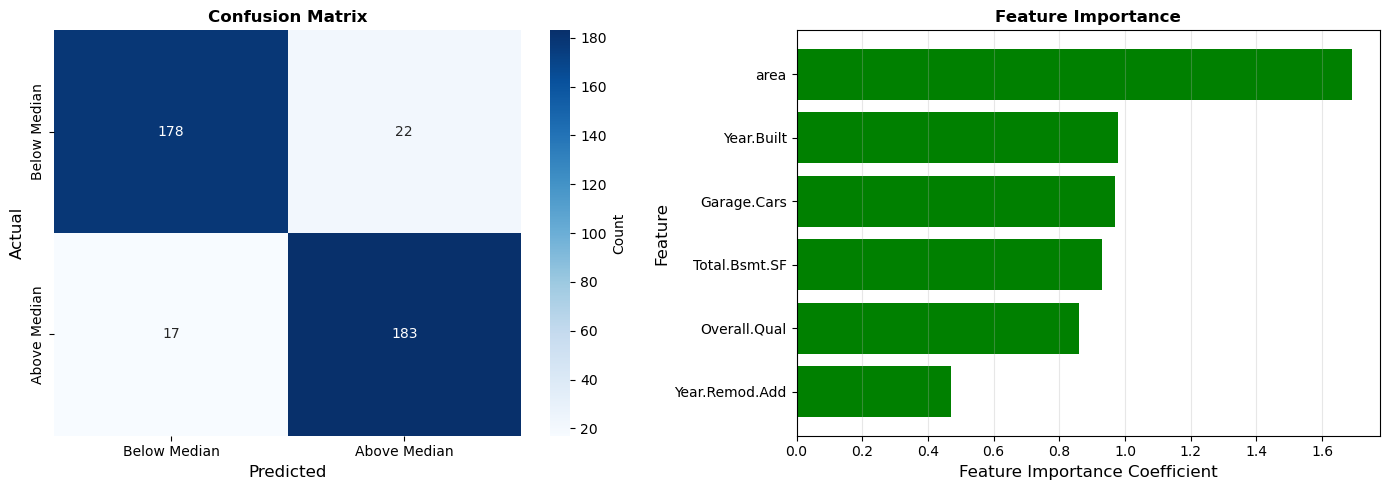

 True Negative (correctly predicted below median): 178
 False Positive (predicted above, actually below): 22
 False Negative (predicted below, actually above): 17
 True Positive (correctly predicted above median): 183


In [61]:
confusion = metrics.confusion_matrix(Y_model, predictions_scaled)

fig10, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))

# Confusion matrix heatmap
sns.heatmap(confusion, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = ['Below Median', 'Above Median'], yticklabels = ['Below Median', 'Above Median'], ax = ax1, cbar_kws = {'label': 'Count'})
ax1.set_xlabel('Predicted', fontsize = 12)
ax1.set_ylabel('Actual', fontsize = 12)
ax1.set_title('Confusion Matrix', fontsize = 12, fontweight = 'bold')


# Feature importance bar chart
feature_importance_sorted = feature_importance_scaled.sort_values('Standardized_Coefficient', ascending = True)
ax2.barh(feature_importance_sorted['Feature'], feature_importance_sorted['Standardized_Coefficient'], color = 'green')
ax2.set_xlabel('Feature Importance Coefficient', fontsize = 12)
ax2.set_ylabel('Feature', fontsize = 12)
ax2.set_title('Feature Importance', fontsize = 12, fontweight = 'bold')
ax2.grid(axis = 'x', alpha = 0.3)

plt.tight_layout()
plt.show()

print(f' True Negative (correctly predicted below median): {confusion[0,0]}')
print(f' False Positive (predicted above, actually below): {confusion[0,1]}')
print(f' False Negative (predicted below, actually above): {confusion[1,0]}')
print(f' True Positive (correctly predicted above median): {confusion[1,1]}')

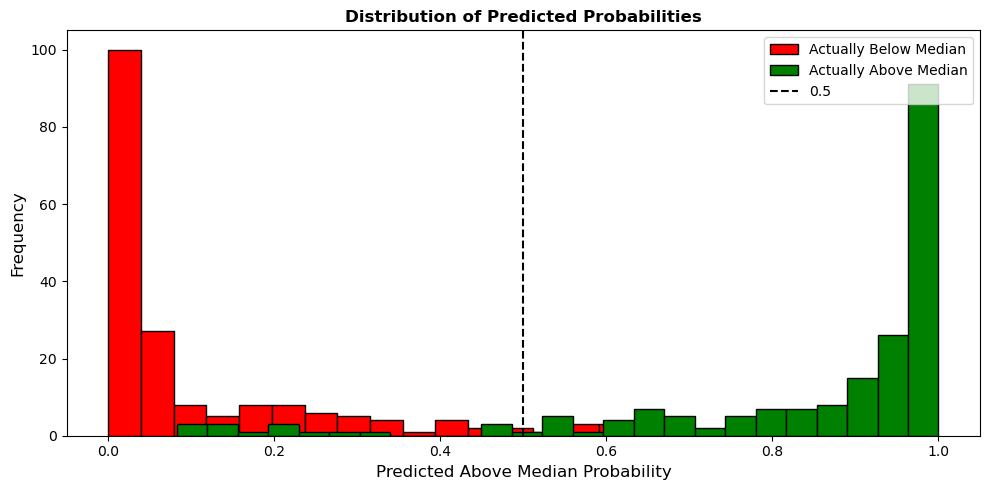

In [62]:
fig11, ax = plt.subplots(1, 1, figsize = (10, 5))

# Histogram of predicted probabilities
below_median = probabilities_scaled[Y_model == 0]
above_median = probabilities_scaled[Y_model == 1]

ax.hist(below_median, bins = 25, label = 'Actually Below Median', color = 'red', edgecolor = 'black')
ax.hist(above_median, bins = 25, label = 'Actually Above Median', color = 'green', edgecolor = 'black')
ax.axvline(x = 0.5, color = 'black', linestyle = '--', label = 0.5)
ax.set_xlabel('Predicted Above Median Probability', fontsize = 12)
ax.set_ylabel('Frequency', fontsize = 12)
ax.set_title('Distribution of Predicted Probabilities', fontsize = 12, fontweight = 'bold')
ax.legend()
plt.tight_layout()
plt.show()